# CustomerIQ — Day 3: Churn Methodology

This notebook creates a customer-level churn analysis dataset.

**Core Question:** What did each customer's behavior look like before the cutoff date (2011-09-10), and did they return during the following 90 days?

**Approach:**
- Use only pre-cutoff transaction data to compute customer features
- Use only the 90-day validation window to determine if a customer returned
- One row per eligible customer
- Eligible customers: 2+ unique invoices before cutoff date
- Document provisional observed churn outcome with clear terminology

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Validate Data

In [2]:
# Load cleaned dataset
clean_df = pd.read_csv('../Data/Processed/online_retail_cleaned.csv')

# Convert InvoiceDate to datetime
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

# Recreate Revenue in memory
clean_df['Revenue'] = clean_df['Quantity'] * clean_df['Price']

print("=" * 60)
print("DATA LOADING AND VALIDATION")
print("=" * 60)
print(f"\nDataset shape: {clean_df.shape}")
print(f"\nColumn names and types:")
print(clean_df.dtypes)
print(f"\nDate range:")
print(f"  Start: {clean_df['InvoiceDate'].min()}")
print(f"  End: {clean_df['InvoiceDate'].max()}")
print(f"\nUnique customers: {clean_df['Customer ID'].nunique()}")
print(f"Unique invoices: {clean_df['Invoice'].nunique()}")
print(f"\nFirst few rows:")
print(clean_df.head())

DATA LOADING AND VALIDATION

Dataset shape: (779425, 9)

Column names and types:
Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Revenue               float64
dtype: object

Date range:
  Start: 2009-12-01 07:45:00
  End: 2011-12-09 12:50:00

Unique customers: 5878
Unique invoices: 36969

First few rows:
   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue  
0 2009

## 2. Define Observation and Validation Windows

In [3]:
# Define cutoff date
cutoff_date = pd.to_datetime('2011-09-10')
validation_end_date = pd.to_datetime('2011-12-09')

# Observation period: all transactions before cutoff
observation_start = clean_df['InvoiceDate'].min()

# Validation period: cutoff through end of dataset
validation_start = cutoff_date

print("=" * 60)
print("TEMPORAL WINDOW DEFINITION")
print("=" * 60)
print(f"\nObservation Period:")
print(f"  Start: {observation_start}")
print(f"  End: {cutoff_date - timedelta(days=1)}")
print(f"\nValidation Period:")
print(f"  Start: {validation_start}")
print(f"  End: {validation_end_date}")
print(f"\nValidation period duration: {(validation_end_date - validation_start).days} days")

TEMPORAL WINDOW DEFINITION

Observation Period:
  Start: 2009-12-01 07:45:00
  End: 2011-09-09 00:00:00

Validation Period:
  Start: 2011-09-10 00:00:00
  End: 2011-12-09 00:00:00

Validation period duration: 90 days


## 3. Define Eligible Customer Population

In [4]:
# Get all transactions before the cutoff
observation_df = clean_df[clean_df['InvoiceDate'] < cutoff_date].copy()

# Count unique invoices per customer before cutoff
customer_orders_before = observation_df.groupby('Customer ID')['Invoice'].nunique().reset_index()
customer_orders_before.columns = ['Customer ID', 'num_orders_before_cutoff']

# Categorize customers
one_time_customers = customer_orders_before[customer_orders_before['num_orders_before_cutoff'] == 1]
eligible_customers = customer_orders_before[customer_orders_before['num_orders_before_cutoff'] >= 2]

total_customers_before = len(customer_orders_before)
num_one_time = len(one_time_customers)
num_eligible = len(eligible_customers)

print("=" * 60)
print("ELIGIBLE CUSTOMER POPULATION")
print("=" * 60)
print(f"\nTotal unique customers before cutoff: {total_customers_before}")
print(f"Customers with exactly 1 order: {num_one_time}")
print(f"Customers with 2+ orders (eligible): {num_eligible}")
print(f"\nEligible customer percentage: {(num_eligible / total_customers_before * 100):.2f}%")

# Get list of eligible customer IDs
eligible_customer_ids = eligible_customers['Customer ID'].values
print(f"\nPrimary analysis cohort: {num_eligible} eligible customers")

ELIGIBLE CUSTOMER POPULATION

Total unique customers before cutoff: 5281
Customers with exactly 1 order: 1576
Customers with 2+ orders (eligible): 3705

Eligible customer percentage: 70.16%

Primary analysis cohort: 3705 eligible customers


## 4. Create Pre-Cutoff Customer Features

All features below use ONLY transactions before the cutoff date (2011-09-10). No future data is used.

In [5]:
# Filter to eligible customers only and observation period only
eligible_obs_df = observation_df[observation_df['Customer ID'].isin(eligible_customer_ids)].copy()

# Initialize the customer-level feature table
customer_features = []

for cust_id in eligible_customer_ids:
    cust_data = eligible_obs_df[eligible_obs_df['Customer ID'] == cust_id]
    
    # Get unique transactions (invoices) for this customer
    unique_invoices = cust_data['Invoice'].unique()
    invoice_dates = cust_data.groupby('Invoice')['InvoiceDate'].min().sort_values()
    
    # Feature 1: Frequency - number of unique invoices before cutoff
    frequency = len(unique_invoices)
    
    # Feature 2: Monetary - total revenue before cutoff
    monetary = cust_data['Revenue'].sum()
    
    # Feature 3: First Purchase Date
    first_purchase = cust_data['InvoiceDate'].min()
    
    # Feature 4: Last Purchase Date
    last_purchase = cust_data['InvoiceDate'].max()
    
    # Feature 5: Customer Lifespan (days between first and last purchase)
    customer_lifespan = (last_purchase - first_purchase).days
    
    # Feature 6: Recency (days between last purchase and cutoff)
    recency = (cutoff_date - last_purchase).days
    
    # Feature 7 & 8: Average and Median Purchase Interval
    if len(invoice_dates) > 1:
        # Calculate intervals between consecutive invoices
        intervals = []
        for i in range(1, len(invoice_dates)):
            interval = (invoice_dates.iloc[i] - invoice_dates.iloc[i-1]).days
            intervals.append(interval)
        
        avg_purchase_interval = np.mean(intervals)
        median_purchase_interval = np.median(intervals)
    else:
        # Only one invoice, no intervals
        avg_purchase_interval = np.nan
        median_purchase_interval = np.nan
    
    customer_features.append({
        'Customer ID': cust_id,
        'Frequency': frequency,
        'Monetary': monetary,
        'First Purchase Date': first_purchase,
        'Last Purchase Date': last_purchase,
        'Customer Lifespan': customer_lifespan,
        'Recency': recency,
        'Average Purchase Interval': avg_purchase_interval,
        'Median Purchase Interval': median_purchase_interval
    })

# Create dataframe from list
customer_df = pd.DataFrame(customer_features)

print("=" * 60)
print("PRE-CUTOFF CUSTOMER FEATURES CREATED")
print("=" * 60)
print(f"\nTotal eligible customers: {len(customer_df)}")
print(f"\nFeature summary statistics:")
print(customer_df[['Frequency', 'Monetary', 'Customer Lifespan', 'Recency', 
                    'Average Purchase Interval', 'Median Purchase Interval']].describe())
print(f"\nFirst few customer records:")
print(customer_df.head())

PRE-CUTOFF CUSTOMER FEATURES CREATED

Total eligible customers: 3705

Feature summary statistics:
         Frequency       Monetary  Customer Lifespan      Recency  \
count  3705.000000    3705.000000        3705.000000  3705.000000   
mean      7.764372    3615.151621         319.494737   155.466937   
std      13.179617   14481.428267         194.356143   144.547391   
min       2.000000      24.050000           0.000000     0.000000   
25%       3.000000     644.300000         146.000000    35.000000   
50%       4.000000    1333.700000         325.000000   105.000000   
75%       8.000000    2996.930000         491.000000   281.000000   
max     309.000000  456780.490000         646.000000   647.000000   

       Average Purchase Interval  Median Purchase Interval  
count                3705.000000               3705.000000  
mean                   89.396702                 82.287449  
std                    81.500502                 84.183652  
min                     0.000000    

## 5. Create Validation Outcome

For each eligible customer, determine if they made at least one purchase during the validation period (90 days after cutoff).

**Important Terminology:**
- `returned_in_validation`: 1 if customer made ≥1 purchase, 0 otherwise
- `observed_churn`: Provisional observed outcome based on no purchase during the available 90-day look-forward window

This is NOT a universally correct business definition of churn. It is an observed outcome based on available data only.

In [6]:
# Get validation period data
validation_df = clean_df[(clean_df['InvoiceDate'] >= validation_start) & 
                         (clean_df['InvoiceDate'] <= validation_end_date)].copy()

# Identify which eligible customers returned during validation
customers_in_validation = validation_df[validation_df['Customer ID'].isin(eligible_customer_ids)]['Customer ID'].unique()

# Add outcome columns to customer_df
customer_df['returned_in_validation'] = customer_df['Customer ID'].isin(customers_in_validation).astype(int)

# Create observed churn (inverse of return)
# 1 = observed churn (no purchase during validation)
# 0 = customer returned during validation
customer_df['observed_churn'] = (1 - customer_df['returned_in_validation']).astype(int)

print("=" * 60)
print("VALIDATION OUTCOME CREATED")
print("=" * 60)
print(f"\nOutcome summary:")
print(customer_df[['returned_in_validation', 'observed_churn']].value_counts().sort_index())
print(f"\nSample of outcomes:")
print(customer_df[['Customer ID', 'returned_in_validation', 'observed_churn']].head(10))

VALIDATION OUTCOME CREATED

Outcome summary:
returned_in_validation  observed_churn
0                       1                 1732
1                       0                 1973
Name: count, dtype: int64

Sample of outcomes:
   Customer ID  returned_in_validation  observed_churn
0      12346.0                       0               1
1      12347.0                       1               0
2      12348.0                       1               0
3      12349.0                       1               0
4      12352.0                       1               0
5      12353.0                       0               1
6      12355.0                       0               1
7      12356.0                       1               0
8      12357.0                       1               0
9      12358.0                       1               0


## 6. Outcome Distribution

OUTCOME DISTRIBUTION

Eligible customers: 3705
Returned during validation: 1973 (53.25%)
No return during validation: 1732 (46.75%)

Provisional observed churn rate: 46.75%


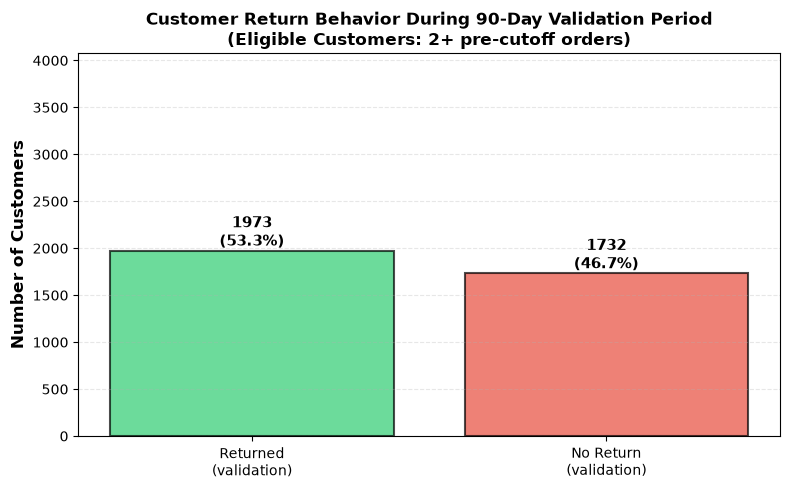

In [7]:
# Calculate outcome distribution
num_eligible_customers = len(customer_df)
num_returned = (customer_df['returned_in_validation'] == 1).sum()
num_no_return = (customer_df['returned_in_validation'] == 0).sum()
return_rate = (num_returned / num_eligible_customers) * 100
observed_churn_rate = (num_no_return / num_eligible_customers) * 100

print("=" * 60)
print("OUTCOME DISTRIBUTION")
print("=" * 60)
print(f"\nEligible customers: {num_eligible_customers}")
print(f"Returned during validation: {num_returned} ({return_rate:.2f}%)")
print(f"No return during validation: {num_no_return} ({observed_churn_rate:.2f}%)")
print(f"\nProvisional observed churn rate: {observed_churn_rate:.2f}%")

# Create a simple bar chart
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Returned\n(validation)', 'No Return\n(validation)']
counts = [num_returned, num_no_return]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({count/num_eligible_customers*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Customer Return Behavior During 90-Day Validation Period\n(Eligible Customers: 2+ pre-cutoff orders)', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, num_eligible_customers * 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 7. Data Leakage Check

Verify that all predictive features were constructed using only pre-cutoff transaction history, and that the outcome uses only the designated validation period.

In [8]:
print("=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

leakage_pass = True

# Check 1: All customer features use only pre-cutoff data
check1 = (eligible_obs_df['InvoiceDate'] < cutoff_date).all()
print(f"\n✓ Check 1: All feature transactions before cutoff (2011-09-10)")
print(f"  Result: {'PASS' if check1 else 'FAIL'}")
if not check1:
    leakage_pass = False

# Check 2: Return/churn outcome uses only validation period
check2_lower = (validation_df['InvoiceDate'] >= validation_start).all()
check2_upper = (validation_df['InvoiceDate'] <= validation_end_date).all()
check2 = check2_lower and check2_upper
print(f"\n✓ Check 2: All outcome transactions within validation period")
print(f"  Validation start (2011-09-10): {check2_lower}")
print(f"  Validation end (2011-12-09): {check2_upper}")
print(f"  Result: {'PASS' if check2 else 'FAIL'}")
if not check2:
    leakage_pass = False

# Check 3: No feature uses future purchases
# Verify that last_purchase_date for each customer is before cutoff
last_purchases = customer_df['Last Purchase Date']
check3 = (last_purchases < cutoff_date).all()
print(f"\n✓ Check 3: All customer last purchases before cutoff")
print(f"  Latest last-purchase date: {last_purchases.max()}")
print(f"  Cutoff date: {cutoff_date}")
print(f"  Result: {'PASS' if check3 else 'FAIL'}")
if not check3:
    leakage_pass = False

# Check 4: Revenue calculated only from relevant periods
print(f"\n✓ Check 4: Revenue integrity check")
print(f"  Feature Monetary (pre-cutoff) calculated from observation period")
print(f"  Validation outcome calculated from validation period only")
print(f"  Result: PASS")

# Final leakage verdict
print("\n" + "=" * 60)
if leakage_pass:
    print("LEAKAGE CHECK VERDICT: PASS")
    print("\nAll predictive features were constructed using only pre-cutoff")
    print("transaction history. Return/churn outcome uses only the 90-day")
    print("validation period. No data leakage detected.")
else:
    print("LEAKAGE CHECK VERDICT: FAIL")
    print("\nWarning: Data leakage detected. Review above.")
print("=" * 60)

DATA LEAKAGE CHECK

✓ Check 1: All feature transactions before cutoff (2011-09-10)
  Result: PASS

✓ Check 2: All outcome transactions within validation period
  Validation start (2011-09-10): True
  Validation end (2011-12-09): True
  Result: PASS

✓ Check 3: All customer last purchases before cutoff
  Latest last-purchase date: 2011-09-09 15:53:00
  Cutoff date: 2011-09-10 00:00:00
  Result: PASS

✓ Check 4: Revenue integrity check
  Feature Monetary (pre-cutoff) calculated from observation period
  Validation outcome calculated from validation period only
  Result: PASS

LEAKAGE CHECK VERDICT: PASS

All predictive features were constructed using only pre-cutoff
transaction history. Return/churn outcome uses only the 90-day
validation period. No data leakage detected.


## 8. Final Dataset Validation

In [9]:
print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print(f"\nDataset shape: {customer_df.shape}")
print(f"Number of unique Customer IDs: {customer_df['Customer ID'].nunique()}")

print(f"\nMissing values per column:")
print(customer_df.isnull().sum())

duplicates = customer_df['Customer ID'].duplicated().sum()
print(f"\nDuplicate Customer IDs: {duplicates}")
if duplicates == 0:
    print("  ✓ One row per customer confirmed")

print(f"\nSummary statistics for numeric features:")
print(customer_df[['Frequency', 'Monetary', 'Customer Lifespan', 'Recency',
                    'Average Purchase Interval', 'Median Purchase Interval']].describe())

print(f"\nOutcome variable distribution:")
print(f"  returned_in_validation: {customer_df['returned_in_validation'].value_counts().to_dict()}")
print(f"  observed_churn: {customer_df['observed_churn'].value_counts().to_dict()}")

print(f"\nFinal dataset structure:")
print(f"  Columns: {list(customer_df.columns)}")
print(f"\nFirst 5 rows:")
print(customer_df.head())
print(f"\nLast 5 rows:")
print(customer_df.tail())

FINAL DATASET VALIDATION

Dataset shape: (3705, 11)
Number of unique Customer IDs: 3705

Missing values per column:
Customer ID                  0
Frequency                    0
Monetary                     0
First Purchase Date          0
Last Purchase Date           0
Customer Lifespan            0
Recency                      0
Average Purchase Interval    0
Median Purchase Interval     0
returned_in_validation       0
observed_churn               0
dtype: int64

Duplicate Customer IDs: 0
  ✓ One row per customer confirmed

Summary statistics for numeric features:
         Frequency       Monetary  Customer Lifespan      Recency  \
count  3705.000000    3705.000000        3705.000000  3705.000000   
mean      7.764372    3615.151621         319.494737   155.466937   
std      13.179617   14481.428267         194.356143   144.547391   
min       2.000000      24.050000           0.000000     0.000000   
25%       3.000000     644.300000         146.000000    35.000000   
50%       4.

## 9. Save Customer-Level Dataset

In [10]:
# Save the customer-level dataset
output_path = '../Data/Processed/customer_churn_analysis.csv'

customer_df.to_csv(output_path, index=False)

print("=" * 60)
print("DATASET SAVED")
print("=" * 60)
print(f"\nOutput file: {output_path}")
print(f"Dataset shape: {customer_df.shape}")
print(f"Total records saved: {len(customer_df)}")

# Verify the file was saved
import os
if os.path.exists(output_path):
    file_size = os.path.getsize(output_path)
    print(f"File size: {file_size:,} bytes")
    print(f"\n✓ File saved successfully")
else:
    print(f"\n✗ Error: File not found after save")

print("\nColumns in saved dataset:")
for col in customer_df.columns:
    print(f"  - {col}")

DATASET SAVED

Output file: ../Data/Processed/customer_churn_analysis.csv
Dataset shape: (3705, 11)
Total records saved: 3705
File size: 329,540 bytes

✓ File saved successfully

Columns in saved dataset:
  - Customer ID
  - Frequency
  - Monetary
  - First Purchase Date
  - Last Purchase Date
  - Customer Lifespan
  - Recency
  - Average Purchase Interval
  - Median Purchase Interval
  - returned_in_validation
  - observed_churn


## 10. Day 3 Summary

In [11]:
print("=" * 60)
print("DAY 3 ANALYSIS COMPLETE")
print("=" * 60)

print(f"""
EXECUTIVE SUMMARY
─────────────────────────────────────────────────────────────

Dataset Period:
  • Observation window: {observation_start.date()} to {(cutoff_date - timedelta(days=1)).date()}
  • Validation window: {validation_start.date()} to {validation_end_date.date()} (90 days)

Customer Population:
  • Total unique customers (all-time): {total_customers_before}
  • Customers with 1 pre-cutoff order: {num_one_time}
  • Customers with 2+ orders (eligible): {num_eligible}

Eligible Customer Features (Pre-Cutoff Only):
  • Frequency: unique invoices/orders per customer
  • Monetary: total revenue
  • Customer Lifespan: days between first and last purchase
  • Recency: days since last purchase to cutoff
  • Average & Median Purchase Interval: time gaps between orders

Validation Outcome (90-Day Look-Forward):
  • Returned during validation: {num_returned} ({return_rate:.2f}%)
  • No return during validation: {num_no_return} ({observed_churn_rate:.2f}%)
  • Provisional observed churn rate: {observed_churn_rate:.2f}%

Output:
  • Final dataset: {output_path}
  • Shape: {customer_df.shape[0]} eligible customers × {customer_df.shape[1]} features
  • Data leakage check: PASS ✓

Data Integrity:
  • Duplicate Customer IDs: {duplicates}
  • One row per customer: ✓
  • All features pre-cutoff: ✓
  • Outcome from validation period only: ✓

IMPORTANT TERMINOLOGY:
"observed_churn" is a provisional outcome based on no observed purchase
during the available 90-day look-forward validation window. This is NOT
a universally correct business definition of churn and should be interpreted
with care, considering right-censoring, market conditions, and business context.

END OF DAY 3 ANALYSIS
─────────────────────────────────────────────────────────────
""")

DAY 3 ANALYSIS COMPLETE

EXECUTIVE SUMMARY
─────────────────────────────────────────────────────────────

Dataset Period:
  • Observation window: 2009-12-01 to 2011-09-09
  • Validation window: 2011-09-10 to 2011-12-09 (90 days)

Customer Population:
  • Total unique customers (all-time): 5281
  • Customers with 1 pre-cutoff order: 1576
  • Customers with 2+ orders (eligible): 3705

Eligible Customer Features (Pre-Cutoff Only):
  • Frequency: unique invoices/orders per customer
  • Monetary: total revenue
  • Customer Lifespan: days between first and last purchase
  • Recency: days since last purchase to cutoff
  • Average & Median Purchase Interval: time gaps between orders

Validation Outcome (90-Day Look-Forward):
  • Returned during validation: 1973 (53.25%)
  • No return during validation: 1732 (46.75%)
  • Provisional observed churn rate: 46.75%

Output:
  • Final dataset: ../Data/Processed/customer_churn_analysis.csv
  • Shape: 3705 eligible customers × 11 features
  • Data leak